<a href="https://colab.research.google.com/github/zhangwiki86-soton/Python-Files-for-Practice/blob/main/Glob%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Data Analysis of WMP

#Clone files from Github

In [ ]:
!pip install panel jupyter_bokeh
!pip install hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.6 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 4.5 MB/s eta 0:00:00


In [ ]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

Cloning into 'L7---Data-Analysis-and-Visualisation'...
remote: Enumerating objects: 391, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 391 (delta 100), reused 28 (delta 28), pack-reused 261 (from 2)
Receiving objects: 100% (391/391), 58.62 MiB | 38.43 MiB/s, done.
Resolving deltas: 100% (239/239), done.


#1. Importing Libriaries

In [ ]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#2. Import Data

In [ ]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

['/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-03-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-08-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-12-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-02-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-11-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-08-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-06-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-10-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-11-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-02-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-06-west-midlands-s

In [ ]:
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)

list_df

[                                               Crime ID    Month  \
 0     4af88c5bdcbf3730c12fd1a5b7fa191967f57817ab7913...  2024-03   
 1     1a706144c188ff118e364ef4fb36043170fdcbdadde299...  2024-03   
 2     f0d59d3d7d36b3f61e0149d4eb0bc414b392816de505a4...  2024-03   
 3     300678bd6320f2023a0b4a3b30c441df497f39866590f7...  2024-03   
 4     d82e2bd21c5897daa655316b626a7dbfd32d3966a17dfc...  2024-03   
 ...                                                 ...      ...   
 7908  419e2e43c2ec00e0bbe7eb727dda5f1fc1611d028bca30...  2024-03   
 7909  7a12645929216de0fef8387ad008b0514b15e341e7e639...  2024-03   
 7910  e2138180fc95d07e93eaa969e8ffb40a6e50bc3861a1fa...  2024-03   
 7911  1853451fc5c71a2fccd16698ee47ea26d09e7e85984794...  2024-03   
 7912  bcfd16539739ead9be32f3b4784897d78cc84bad12a41d...  2024-03   
 
                Reported by          Falls within  Longitude   Latitude  \
 0     Staffordshire Police  Staffordshire Police  -1.811891  52.523477   
 1     Staffordshire

In [ ]:
#Check how many items, expect 24+24=48 of both West Midlands and Staffordshire Police
len(list_df)

48

#Concatenate all CSV into one DataFrame

In [ ]:
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 for row concatenation and 1 is for column
CrimeData

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,4af88c5bdcbf3730c12fd1a5b7fa191967f57817ab7913...,2024-03,Staffordshire Police,Staffordshire Police,-1.811891,52.523477,On or near Chestergate Croft,E01009098,Birmingham 025C,Other crime,Status update unavailable,NaN
1,1a706144c188ff118e364ef4fb36043170fdcbdadde299...,2024-03,Staffordshire Police,Staffordshire Police,-2.532905,51.440345,On or near Wyndham Crescent,E01014526,Bristol 038D,Violence and sexual offences,Unable to prosecute suspect,NaN
2,f0d59d3d7d36b3f61e0149d4eb0bc414b392816de505a4...,2024-03,Staffordshire Police,Staffordshire Police,-1.957113,52.765298,On or near Sheringham Drive,E01029368,Cannock Chase 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
3,300678bd6320f2023a0b4a3b30c441df497f39866590f7...,2024-03,Staffordshire Police,Staffordshire Police,-1.955080,52.767167,On or near Farm Close,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,NaN
4,d82e2bd21c5897daa655316b626a7dbfd32d3966a17dfc...,2024-03,Staffordshire Police,Staffordshire Police,-1.957794,52.765811,On or near Waverley Gardens,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2c57bdf3744930e58f4736fdec63cb2e2188969bd56c07...,2024-01,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,df2ce04ed5d258c487674c161a772fdb473fd360b6b0f4...,2024-01,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,60266b081528550bc2c1db06fd2a31004f06096cefbcb1...,2024-01,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,e78e096e910cc1d52c8635995033fe770d66b24154966c...,2024-01,Staffordshire Police,Staffordshire Police,NaN,NaN,No Location,NaN,NaN,Other crime,Status update unavailable,NaN


#Structure and Shape

In [ ]:
# Dimentions of the DataFrame (number of rows and columns)
CrimeData.shape

(869247, 12)

In [ ]:
#CrimeData.index.to_list()
CrimeData.index

RangeIndex(start=0, stop=869247, step=1)

In [ ]:
print("colomns:\n", CrimeData.columns) # Column names of the DataFrame
#print("colomns:\n", CrimeData.columns.to_list()) # In list

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')


In [ ]:
# number of rows/records
# any null values in each colum, how complete the columns are populated in the dataset
# what are the types of attributes
CrimeData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


#Detecting missing values

In [ ]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


#Check distribution of missing data by key analysis fields
##LOSA and coordinates data are missing some Staffordshire Police data
##All missing last outcome data is concentrated in Anti-social behaviour


In [ ]:
missing_by_reported_by = CrimeData.groupby('Reported by').apply(lambda x: x.isnull().sum())
display(missing_by_reported_by)


/tmp/ipykernel_7560/2182174662.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_reported_by = CrimeData.groupby('Reported by').apply(lambda x: x.isnull().sum())


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
Reported by,,,,,,,,,,,,
Staffordshire Police,27670,0,0,0,931,931,0,931,931,0,27670,201139
West Midlands Police,51667,0,0,0,0,0,0,0,0,0,51667,668108


In [ ]:
missing_by_CT= CrimeData.groupby('Crime type').apply(lambda x: x.isnull().sum())
display(missing_by_CT)

/tmp/ipykernel_7560/4137677165.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_CT= CrimeData.groupby('Crime type').apply(lambda x: x.isnull().sum())


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
Crime type,,,,,,,,,,,,
Anti-social behaviour,79337,0,0,0,1,1,0,1,1,0,79337,79337
Bicycle theft,0,0,0,0,13,13,0,13,13,0,0,5270
Burglary,0,0,0,0,31,31,0,31,31,0,0,40238
Criminal damage and arson,0,0,0,0,72,72,0,72,72,0,0,65244
Drugs,0,0,0,0,31,31,0,31,31,0,0,22044
Other crime,0,0,0,0,17,17,0,17,17,0,0,17516
Other theft,0,0,0,0,76,76,0,76,76,0,0,53835
Possession of weapons,0,0,0,0,10,10,0,10,10,0,0,15190
Public order,0,0,0,0,95,95,0,95,95,0,0,54163


#Select columns, drop columns not needed

In [ ]:
#select Columns needed
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']]
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-03,Staffordshire Police,On or near Chestergate Croft,E01009098,Birmingham 025C,Other crime,Status update unavailable
1,2024-03,Staffordshire Police,On or near Wyndham Crescent,E01014526,Bristol 038D,Violence and sexual offences,Unable to prosecute suspect
2,2024-03,Staffordshire Police,On or near Sheringham Drive,E01029368,Cannock Chase 001A,Violence and sexual offences,Unable to prosecute suspect
3,2024-03,Staffordshire Police,On or near Farm Close,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified
4,2024-03,Staffordshire Police,On or near Waverley Gardens,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2024-01,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869243,2024-01,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869244,2024-01,Staffordshire Police,No Location,NaN,NaN,Violence and sexual offences,Unable to prosecute suspect
869245,2024-01,Staffordshire Police,No Location,NaN,NaN,Other crime,Status update unavailable


In [ ]:
#Double Check if both datasets brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


#!!!!!!!!Reference external data here on if these number of Crimes overal reconcil other national statistics;


# Handling Missing Data

In [ ]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded' for outcome column
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [ ]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-03,Staffordshire Police,On or near Chestergate Croft,E01009098,Birmingham 025C,Other crime,Status update unavailable
1,2024-03,Staffordshire Police,On or near Wyndham Crescent,E01014526,Bristol 038D,Violence and sexual offences,Unable to prosecute suspect
2,2024-03,Staffordshire Police,On or near Sheringham Drive,E01029368,Cannock Chase 001A,Violence and sexual offences,Unable to prosecute suspect
3,2024-03,Staffordshire Police,On or near Farm Close,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified
4,2024-03,Staffordshire Police,On or near Waverley Gardens,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869243,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869244,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect
869245,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Other crime,Status update unavailable


#Handling Data Quality Issue
Review Crimes and Outcomes, check any duplication/Similar inputs to tidy up

In [ ]:
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


In [ ]:
# Fix typo and duplications
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


#1.   Bring in workforce data
#2.   Import LSOA data
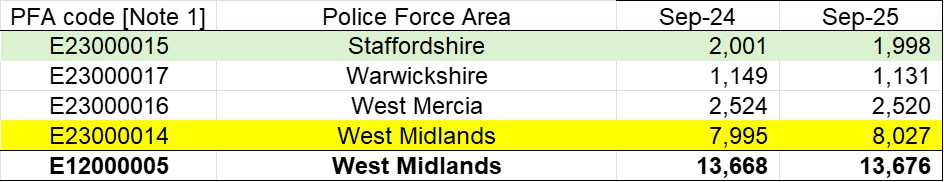


In [ ]:
#Create DataFrame FTE
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


#Merge supplimentary datasets
Append Police Work Force Data and LSOA data to main crime data

In [ ]:
#Bring in IMD Scores and LSOA population data
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Barriers to Housing and Services Score,Barriers to Housing and Services Rank (where 1 is most deprived),Barriers to Housing and Services Decile (where 1 is most deprived 10% of LSOAs),Living Environment Score,Living Environment Rank (where 1 is most deprived),Living Environment Decile (where 1 is most deprived 10% of LSOAs),Income Deprivation Affecting Children Index (IDACI) Score (rate),Income Deprivation Affecting Children Index (IDACI) Rank (where 1 is most deprived),Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs),Population LSOA
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,33730,10,...,10.950,29220,9,69.345,244,1,0.039,33304,10,1795
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,33669,10,...,6.703,32640,10,43.890,3702,2,0.076,31744,10,1671
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,25167,8,...,9.735,30400,10,41.163,4540,2,0.250,19647,6,1896
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,14836,5,...,24.623,11294,4,38.695,5403,2,0.459,9604,3,1737
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,7519,3,...,38.025,2745,1,29.616,9479,3,0.640,3669,2,1837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,7.945,27536,9,0.101,25934,8,...,15.321,23743,8,8.503,25435,8,0.192,23609,7,1154
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,7.622,27902,9,0.097,26440,8,...,23.669,12406,4,5.731,28626,9,0.162,25922,8,1640
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,7.946,27532,9,0.170,18127,6,...,10.074,30084,9,3.450,31180,10,0.206,22526,7,1693
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,6.682,28981,9,0.136,21596,7,...,19.265,18053,6,4.985,29506,9,0.212,22148,7,1690


#Keep relevant columns from LSOA data

In [ ]:
#select Columns needed
LSOAdataclean=LSOAdata.loc[:, [
    'LSOA code (2021)',
    'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
    'Barriers to Housing and Services Score',
    'Living Environment Score',
    'Income Deprivation Affecting Children Index (IDACI) Score (rate)',
    'Population LSOA'
    ]]
#Rename Column for easy merge
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA
0,E01000001,8,8.742,0.013,0.014,0.004,-1.771,-2.220,10.950,69.345,0.039,1795
1,E01000002,10,4.722,0.018,0.010,0.169,-1.549,-2.277,6.703,43.890,0.076,1671
2,E01000003,8,9.250,0.107,0.064,3.269,-0.292,-0.765,9.735,41.163,0.250,1896
3,E01000005,5,19.884,0.211,0.104,17.852,0.436,-0.626,24.623,38.695,0.459,1737
4,E01000006,4,25.307,0.343,0.120,25.442,-0.372,-0.072,38.025,29.616,0.640,1837
...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,9,7.945,0.101,0.074,10.893,-1.004,0.215,15.321,8.503,0.192,1154
33751,E01035759,9,7.622,0.097,0.081,7.528,-0.645,-1.047,23.669,5.731,0.162,1640
33752,E01035760,9,7.946,0.170,0.067,10.064,-0.743,-0.157,10.074,3.450,0.206,1693
33753,E01035761,9,6.682,0.136,0.054,8.482,-0.938,-0.566,19.265,4.985,0.212,1690


In [ ]:
#Observe data for any outliers or potential data quality issue
LSOAdataclean.describe().round(1)
#LSOAdata['Education, Skills and Training Score'].describe().round(1)

,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA
count,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0,33755.0
mean,5.5,21.7,0.2,0.1,21.7,0.0,-0.0,21.7,21.7,0.3,1692.0
std,2.9,15.7,0.2,0.1,18.1,0.9,0.8,10.2,16.1,0.2,373.9
min,1.0,0.2,0.0,0.0,0.0,-3.1,-3.3,1.5,0.1,0.0,940.0
25%,3.0,9.7,0.1,0.1,7.5,-0.6,-0.6,14.1,8.6,0.2,1448.0
50%,6.0,17.4,0.2,0.1,16.5,-0.0,-0.0,20.1,17.8,0.3,1620.0
75%,8.0,29.7,0.3,0.2,31.2,0.6,0.6,27.6,31.7,0.5,1857.0
max,10.0,94.2,1.0,1.0,99.6,3.3,3.5,63.5,85.7,1.0,9512.0


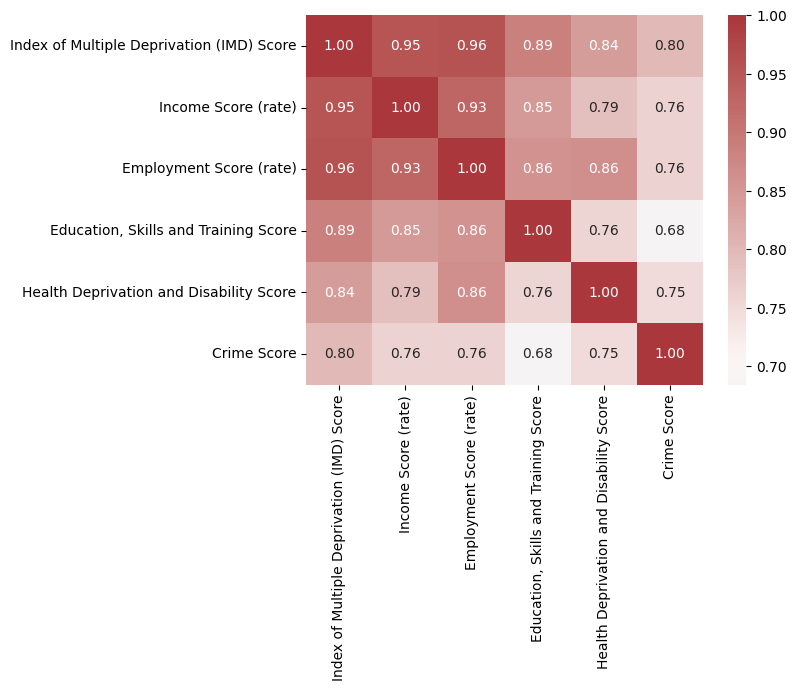

In [ ]:
num_cols = [
    'Index of Multiple Deprivation (IMD) Score',
    'Income Score (rate)',
    'Employment Score (rate)',
    'Education, Skills and Training Score',
    'Health Deprivation and Disability Score',
    'Crime Score',
    ]
sns.heatmap(LSOAdataclean[num_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0.7)
plt.show()
#plt.tight_layout()

#Merge all datasets

In [ ]:
#Merge LSOA data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA,Police FTE
0,2024-03,Staffordshire Police,On or near Chestergate Croft,E01009098,Birmingham 025C,Other crime,Status update unavailable,2.0,37.498,0.398,0.232,37.526,1.161,0.637,24.975,16.182,0.544,2108.0,1998
1,2024-03,Staffordshire Police,On or near Wyndham Crescent,E01014526,Bristol 038D,Violence and sexual offences,Unable to prosecute suspect,2.0,35.596,0.387,0.223,54.880,0.617,0.402,21.450,16.912,0.617,1617.0,1998
2,2024-03,Staffordshire Police,On or near Sheringham Drive,E01029368,Cannock Chase 001A,Violence and sexual offences,Unable to prosecute suspect,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998
3,2024-03,Staffordshire Police,On or near Farm Close,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998
4,2024-03,Staffordshire Police,On or near Waverley Gardens,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998
869243,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998
869244,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998
869245,2024-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Other crime,Status update unavailable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998


#Creat months group for first and second 12 months for "Year on Year" comparision

In [ ]:
#change data type for Column "Month"
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')
DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Index of Multiple Deprivation (IMD) Score,Income Score (rate),Employment Score (rate),"Education, Skills and Training Score",Health Deprivation and Disability Score,Crime Score,Barriers to Housing and Services Score,Living Environment Score,Income Deprivation Affecting Children Index (IDACI) Score (rate),Population LSOA,Police FTE,Month Group
0,2024-03-01,Staffordshire Police,On or near Chestergate Croft,E01009098,Birmingham 025C,Other crime,Status update unavailable,2.0,37.498,0.398,0.232,37.526,1.161,0.637,24.975,16.182,0.544,2108.0,1998,first 12 months
1,2024-03-01,Staffordshire Police,On or near Wyndham Crescent,E01014526,Bristol 038D,Violence and sexual offences,Unable to prosecute suspect,2.0,35.596,0.387,0.223,54.880,0.617,0.402,21.450,16.912,0.617,1617.0,1998,first 12 months
2,2024-03-01,Staffordshire Police,On or near Sheringham Drive,E01029368,Cannock Chase 001A,Violence and sexual offences,Unable to prosecute suspect,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998,first 12 months
3,2024-03-01,Staffordshire Police,On or near Farm Close,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998,first 12 months
4,2024-03-01,Staffordshire Police,On or near Waverley Gardens,E01029368,Cannock Chase 001A,Vehicle crime,Investigation complete; no suspect identified,10.0,4.695,0.041,0.056,10.123,-0.432,-1.065,14.580,7.204,0.081,1176.0,1998,first 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-01-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869243,2024-01-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869244,2024-01-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Violence and sexual offences,Unable to prosecute suspect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,first 12 months
869245,2024-01-01,Staffordshire Police,No Location,Data not recorded,Data not recorded,Other crime,Status update unavailable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998,first 12 months


#Analysis and Visualisation

#Need to be able to have view for WMP and SP both

https://www.plumplot.co.uk/West-Midlands-drugs-crime-statistics.html#:~:text=West%20Midlands%20drugs%20crime%20rate%20compared%20to%20other%20regions,annual%20change%2C%20crime%20is%20increasing

# 1. Is West Midlands Police's performance improving over the 24 months time - compare the first 12 months and the second 12 months

In [ ]:
# Data transformation
crime_counts = DataMerge.groupby(['Reported by','Month Group']).size().reset_index(name='CrimeCount')
crime_counts

,Reported by,Month Group,CrimeCount
0,Staffordshire Police,first 12 months,99527
1,Staffordshire Police,second 12 months,101612
2,West Midlands Police,first 12 months,344501
3,West Midlands Police,second 12 months,323607


##1.1 West Midlands Crime Decreased by 6.1% from the first 12 months to the second 12 months. At the same time, staffordshire police saw increase of crime

In [ ]:
#Pivot crime_counts table, use 'Month Group' as column headers
crime_counts_pivot = crime_counts.pivot_table(index='Reported by', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot.columns.name = None # Remove the 'Month Group' name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot ['Variance %'] =(crime_counts_pivot['second 12 months']-crime_counts_pivot['first 12 months'])/crime_counts_pivot['first 12 months']*100
crime_counts_pivot ['Variance %'] = crime_counts_pivot['Variance %'].round(1)
crime_counts_pivot

,Reported by,first 12 months,second 12 months,Variance %
0,Staffordshire Police,99527.0,101612.0,2.1
1,West Midlands Police,344501.0,323607.0,-6.1


In [ ]:
#Which LSOA is the worst, any change the Year on Year

# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='LSOA name', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
#crime_counts_pivot1.head(10)
crime_counts_pivot1.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot1.sort_values(by=["Variance %"],ascending=True)

,LSOA name,first 12 months,second 12 months,Variance %
629,Birmingham 138A,5751.0,6246.0,8.6
1546,Walsall 030A,2442.0,2259.0,-7.5
809,Coventry 031E,2043.0,2241.0,9.7
614,Birmingham 135C,2330.0,1928.0,-17.3
236,Birmingham 050E,1863.0,1916.0,2.8
1695,Wolverhampton 020H,1964.0,1887.0,-3.9
237,Birmingham 050F,2124.0,1704.0,-19.8
810,Coventry 031F,1983.0,1670.0,-15.8
1314,Solihull 009A,1584.0,1373.0,-13.3
155,Birmingham 033F,1172.0,1232.0,5.1


In [ ]:
#Which Location is the worst, any change Year on Year

# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['Location','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot2 = crime_counts_type_wmp.pivot_table(index='Location', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2 ['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
#crime_counts_pivot1.head(10)
crime_counts_pivot2.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot1.sort_values(by=["Variance %"],ascending=True)

,Location,first 12 months,second 12 months,Variance %
13043,On or near Parking Area,16164.0,15585.0,-3.6
16438,On or near Supermarket,15568.0,14757.0,-5.2
13358,On or near Petrol Station,9582.0,8987.0,-6.2
15332,On or near Shopping Area,9464.0,8918.0,-5.8
8859,On or near Hospital,2815.0,2560.0,-9.1
15736,On or near Sports/Recreation Area,2134.0,2345.0,9.9
8392,On or near High Street,2074.0,2070.0,-0.2
12277,On or near Nightclub,2126.0,1705.0,-19.8
6766,On or near Further/Higher Educational Building,1833.0,1546.0,-15.7
12163,On or near New Street,1307.0,1344.0,2.8


#Birmingham 138A drill down

In [ ]:
#Which Location is the worst, any change Year on Year

# West Midlands Police - Birmingham 138A
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Location','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['LSOA name'] == 'Birmingham 138A']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot3 = crime_counts_type_wmp.pivot_table(index='Location', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot3.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot3 ['Variance %'] =(crime_counts_pivot3['second 12 months']-crime_counts_pivot3['first 12 months'])/crime_counts_pivot3['first 12 months']*100
crime_counts_pivot3 ['Variance %'] = crime_counts_pivot3['Variance %'].round(1)
#crime_counts_pivot1.head(10)
crime_counts_pivot3.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot1.sort_values(by=["Variance %"],ascending=True)

,Location,first 12 months,second 12 months,Variance %
21,On or near Worcester Street,988.0,1259.0,27.4
10,On or near High Street,854.0,983.0,15.1
12,On or near New Street,768.0,825.0,7.4
17,On or near Supermarket,760.0,715.0,-5.9
16,On or near Shopping Area,733.0,649.0,-11.5
6,On or near Conference/Exhibition Centre,163.0,465.0,185.3
15,On or near Parking Area,385.0,204.5,-46.9
19,On or near Temple Street,144.0,147.0,2.1
5,On or near Colmore Row,109.0,105.0,-3.7
3,On or near Bennett'S Hill,80.0,104.0,30.0


#Join this data with Lo and La for map plot

In [ ]:
map_data1=crime_counts_pivot3.sort_values(by=["second 12 months"],ascending=False).head(10)
map_data1=map_data1.loc[:,['Location','Variance %','second 12 months']]
map_data2=CrimeData.loc[:,['Location','LSOA name','Longitude','Latitude']]
map_data2=map_data2[map_data2['LSOA name'] == 'Birmingham 138A']
map_data2=map_data2.drop_duplicates(subset=['Location','Longitude', 'Latitude'])
map_data=pd.merge(map_data1,map_data2,on='Location',how='left')
map_data.drop([5,6,9], inplace=True) # drop wrong coordinates
map_data

,Location,Variance %,second 12 months,LSOA name,Longitude,Latitude
0,On or near Worcester Street,27.4,1259.0,Birmingham 138A,-1.895744,52.478083
1,On or near High Street,15.1,983.0,Birmingham 138A,-1.894592,52.479565
2,On or near New Street,7.4,825.0,Birmingham 138A,-1.898553,52.479128
3,On or near Supermarket,-5.9,715.0,Birmingham 138A,-1.897764,52.482804
4,On or near Shopping Area,-11.5,649.0,Birmingham 138A,-1.896088,52.480169
7,On or near Conference/Exhibition Centre,185.3,465.0,Birmingham 138A,-1.903746,52.481497
8,On or near Parking Area,-46.9,204.5,Birmingham 138A,-1.902013,52.479266
10,On or near Temple Street,2.1,147.0,Birmingham 138A,-1.899273,52.479785
11,On or near Colmore Row,-3.7,105.0,Birmingham 138A,-1.899623,52.481430
12,On or near Bennett'S Hill,30.0,104.0,Birmingham 138A,-1.900392,52.480109


In [ ]:
!pip install geoviews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 74.0 MB/s eta 0:00:00


In [ ]:
from contextlib import redirect_stderr
map_plot = map_data.hvplot.points(
    x='Longitude',
    y='Latitude',
    s='second 12 months',
    color='Variance %',
    cmap='RdYlGn_r',
    geo=True,
    tiles='OSM', # OpenStreetMap tiles
    frame_width=800,
    frame_height=500,
    hover_cols=['Location','Variance %'], # Display Location, CrimeCount, Variance % on hover
    title='Top 10 Locations by Crime Count - LSOA Birmingham 138A'
)
map_plot

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (Variance %,second 12 months,Location)

In [ ]:
#Which Crime Type is the worst, change Year on Year

# West Midlands Police - Birmingham 138A
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['LSOA name','Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['LSOA name'] == 'Birmingham 138A']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot4 = crime_counts_type_wmp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot4.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot4 ['Variance %'] =(crime_counts_pivot4['second 12 months']-crime_counts_pivot4['first 12 months'])/crime_counts_pivot4['first 12 months']*100
crime_counts_pivot4 ['Variance %'] = crime_counts_pivot4['Variance %'].round(1)
#crime_counts_pivot4.head(10)
crime_counts_pivot4.sort_values(by=["second 12 months"],ascending=False).head(10)
#crime_counts_pivot4.sort_values(by=["Variance %"],ascending=True)
heatmap_data=crime_counts_pivot4.sort_values(by=["second 12 months"],ascending=False).head(10)
heatmap_data
heatmap_data=heatmap_data.sort_values(by=["Variance %"],ascending=False)

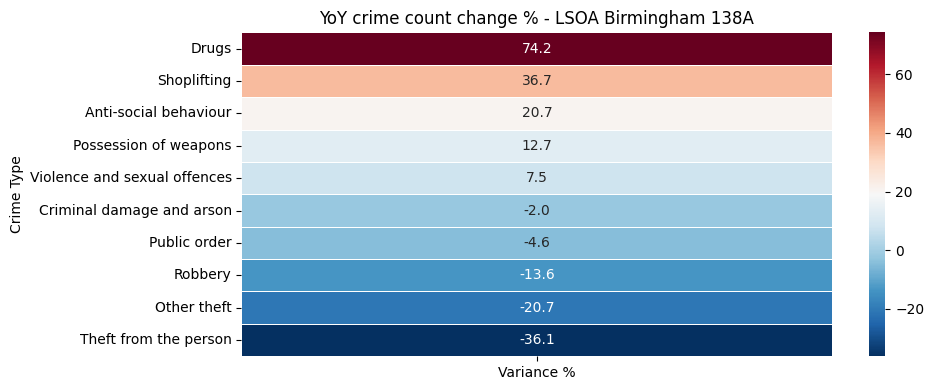

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data.set_index('Crime type')[['Variance %']], annot=True, fmt=".1f", cmap="RdBu_r", linewidths=.5)
plt.title('YoY crime count change % - LSOA Birmingham 138A')
#plt.xlabel('Variance %')
plt.ylabel('Crime Type')
plt.tight_layout()
plt.show()

##1.2 Which type of crime presented the biggest change over the observed period (first 12 months vs the second 12 months) -  West Midlands and Staffordshore Police respectively

In [ ]:
# West Midlands Police
# Variance number of crimes by types
crime_counts_type_wmp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_wmp
crime_counts_type_wmp=crime_counts_type_wmp[crime_counts_type_wmp['Reported by'] == 'West Midlands Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot1 = crime_counts_type_wmp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot1.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot1 ['Variance %'] =(crime_counts_pivot1['second 12 months']-crime_counts_pivot1['first 12 months'])/crime_counts_pivot1['first 12 months']*100
crime_counts_pivot1 ['Variance %'] = crime_counts_pivot1['Variance %'].round(1)
crime_counts_pivot1.sort_values(by=["Variance %"],ascending=False)

,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,7728.0,9277.0,20.0
10,Shoplifting,30229.0,32263.0,6.7
7,Possession of weapons,6356.0,6590.0,3.7
13,Violence and sexual offences,135136.0,131446.0,-2.7
3,Criminal damage and arson,25711.0,24600.0,-4.3
5,Other crime,6782.0,6427.0,-5.2
11,Theft from the person,2950.0,2663.0,-9.7
1,Bicycle theft,2011.0,1811.0,-9.9
8,Public order,19995.0,17464.0,-12.7
0,Anti-social behaviour,27784.0,23883.0,-14.0


In [ ]:
# Staffordshire Police
# Variance number of crimes by types
crime_counts_type_sp = DataMerge.groupby(['Crime type','Month Group','Reported by']).size().reset_index(name='CrimeCount')
crime_counts_type_sp
crime_counts_type_sp=crime_counts_type_sp[crime_counts_type_sp['Reported by'] == 'Staffordshire Police']
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot2 = crime_counts_type_sp.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2 ['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["Variance %"],ascending=False)


,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,1926.0,3113.0,61.6
0,Anti-social behaviour,12414.0,15256.0,22.9
9,Robbery,826.0,1000.0,21.1
5,Other crime,1987.0,2320.0,16.8
7,Possession of weapons,1085.0,1159.0,6.8
8,Public order,8254.0,8450.0,2.4
13,Violence and sexual offences,40721.0,41009.0,0.7
10,Shoplifting,7380.0,6991.0,-5.3
3,Criminal damage and arson,7740.0,7193.0,-7.1
12,Vehicle crime,5209.0,4758.0,-8.7


In [ ]:
MergeCompare=pd.merge(crime_counts_pivot1,crime_counts_pivot2,on='Crime type',how='left')
MergeCompare=MergeCompare.loc[:, ['Crime type','Variance %_x','Variance %_y']]
MergeCompare.rename(columns={'Variance %_x':'Variance % West Midlands Police','Variance %_y':'Variance % Staffordshire Police'}, inplace=True)
MergeCompare

,Crime type,Variance % West Midlands Police,Variance % Staffordshire Police
0,Anti-social behaviour,-14.0,22.9
1,Bicycle theft,-9.9,-9.7
2,Burglary,-17.6,-20.6
3,Criminal damage and arson,-4.3,-7.1
4,Drugs,20.0,61.6
5,Other crime,-5.2,16.8
6,Other theft,-15.2,-9.0
7,Possession of weapons,3.7,6.8
8,Public order,-12.7,2.4
9,Robbery,-15.0,21.1


In [ ]:
MergeCompare_unpivoted = pd.melt(MergeCompare, id_vars=['Crime type'], value_vars=['Variance % West Midlands Police', 'Variance % Staffordshire Police'], var_name='Police Force', value_name='Variance %')
MergeCompare_unpivoted

,Crime type,Police Force,Variance %
0,Anti-social behaviour,Variance % West Midlands Police,-14.0
1,Bicycle theft,Variance % West Midlands Police,-9.9
2,Burglary,Variance % West Midlands Police,-17.6
3,Criminal damage and arson,Variance % West Midlands Police,-4.3
4,Drugs,Variance % West Midlands Police,20.0
5,Other crime,Variance % West Midlands Police,-5.2
6,Other theft,Variance % West Midlands Police,-15.2
7,Possession of weapons,Variance % West Midlands Police,3.7
8,Public order,Variance % West Midlands Police,-12.7
9,Robbery,Variance % West Midlands Police,-15.0


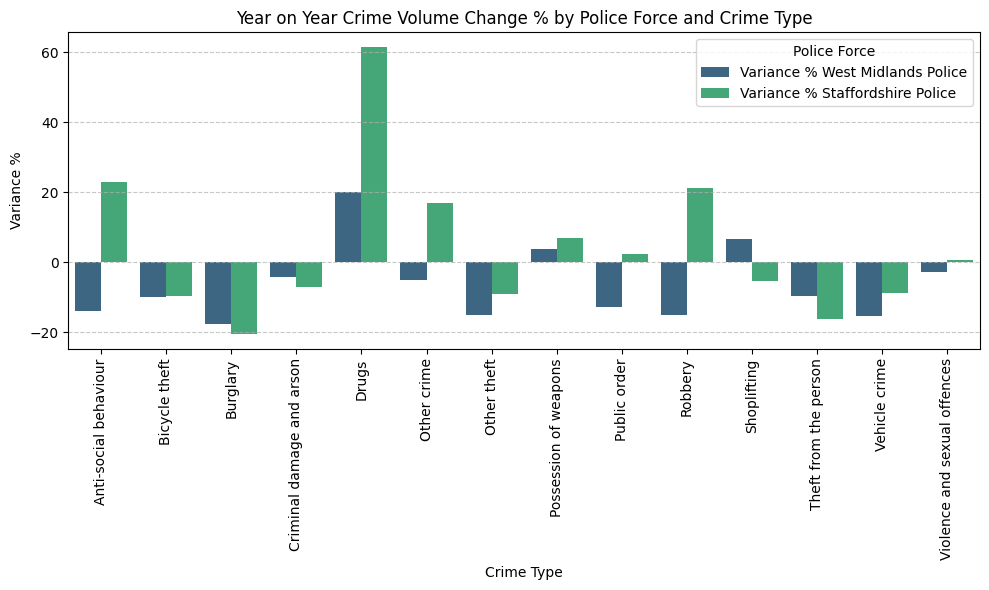

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Crime type', y='Variance %', hue='Police Force', data=MergeCompare_unpivoted, palette='viridis')
plt.title('Year on Year Crime Volume Change % by Police Force and Crime Type')
plt.xlabel('Crime Type')
plt.ylabel('Variance %')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#There are 7.7% and 13.8% of crimes did not have an outcome recorded for West Midlands and staffordshire police repectively, this could potentially skewed the insights, for instance, unproscuted proportion could be even higher or lower than West Midland Police area.

#Creat Radio Botton for Police Force names

In [ ]:
#Prepare data for pipeline
crime_over_time = DataMerge[['Reported by','Crime type','Month']].value_counts().reset_index(name='Count')
display(crime_over_time)
crime_over_time = crime_over_time.interactive()

,Reported by,Crime type,Month,Count
0,West Midlands Police,Violence and sexual offences,2024-05-01,12342
1,West Midlands Police,Violence and sexual offences,2025-07-01,12230
2,West Midlands Police,Violence and sexual offences,2024-07-01,12226
3,West Midlands Police,Violence and sexual offences,2025-06-01,11895
4,West Midlands Police,Violence and sexual offences,2024-06-01,11862
...,...,...,...,...
667,Staffordshire Police,Theft from the person,2025-06-01,18
668,Staffordshire Police,Theft from the person,2025-05-01,17
669,Staffordshire Police,Theft from the person,2024-03-01,15
670,Staffordshire Police,Theft from the person,2025-09-01,13


In [ ]:
#crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Crime type'], columns='Reported by', values='Count').reset_index()
crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Reported by'], columns='Crime type', values='Count').reset_index()
crime_over_time_pivot_full.columns.name = None # Remove the column name for clarity
display(crime_over_time_pivot_full)

In [ ]:
#Creat Radio button for interation with data
yaxis_police = pn.widgets.RadioButtonGroup(
    name='Count of Crime',
    options=['Anti-social behaviour','Bicycle theft','Burglary','Criminal damage and arson','Drugs','Other crime','Other theft','Possession of weapons','Public order','Robbery','Shoplifting','Theft from the person','Vehicle crime','Violence and sexual offences'],
    button_type='primary',
    button_style='outline'
    )
yaxis_police

RadioButtonGroup(button_style='outline', button_type='primary', name='Count of Crime', options=['Anti-social behaviour', ...], value='Anti-social behaviour')

In [ ]:
#Creat Pipeline
crime_pipeline =(
    crime_over_time_pivot_full
    .groupby(['Reported by','Month'])[yaxis_police].sum()
    .reset_index()
    .sort_values(by='Month')
    .reset_index(drop=True)
                 )
crime_pipeline

##Seasonal trend over 24 months - Interactive chart like dashboard, with radio buttons for filtering

In [ ]:
crime_plot=crime_pipeline.hvplot(x='Month', by='Reported by', y=yaxis_police, line_width=2, width=1000, height=400, title ="Crime over time")
crime_plot

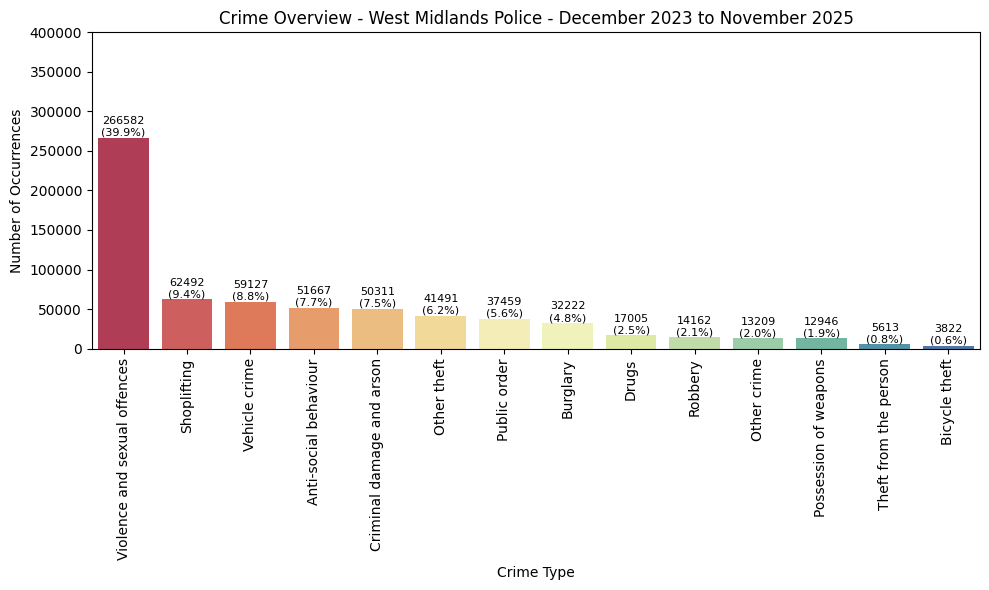

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

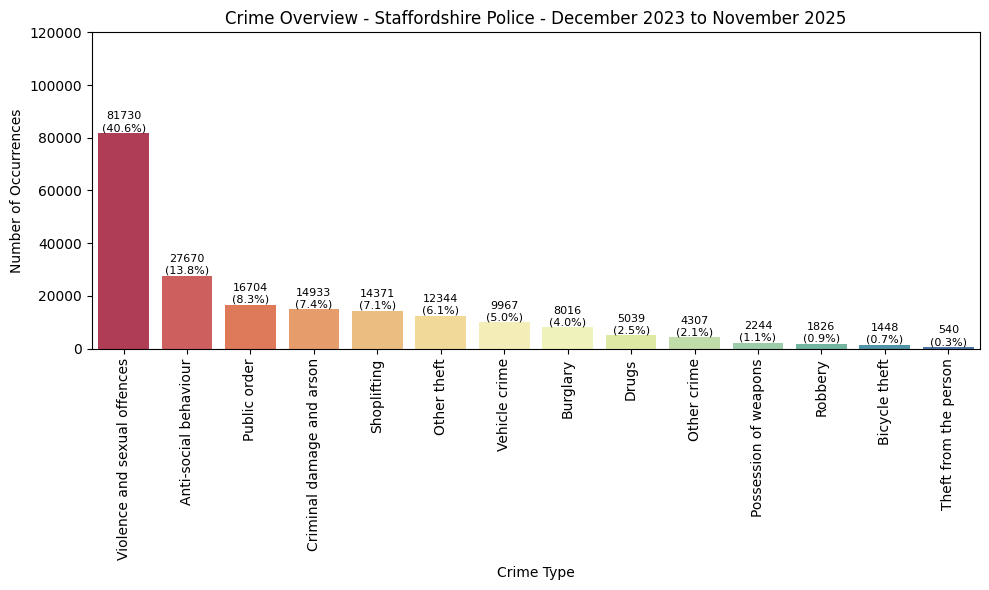

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Police1=['Staffordshire Police']
chart2=CleanData[CleanData['Reported by'].isin(Police1)]
crime_type_counts = chart2['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - Staffordshire Police - December 2023 to November 2025')
plt.ylim(0, 120000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

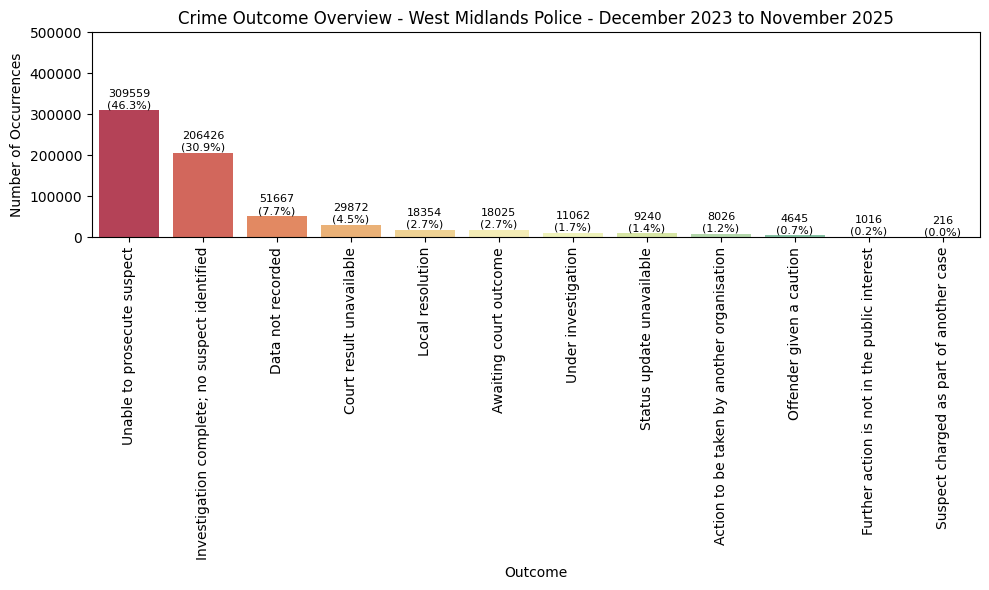

In [ ]:
#Bar Chart with percentages of total %
#Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police)]
outcome_counts = chart1['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 500000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

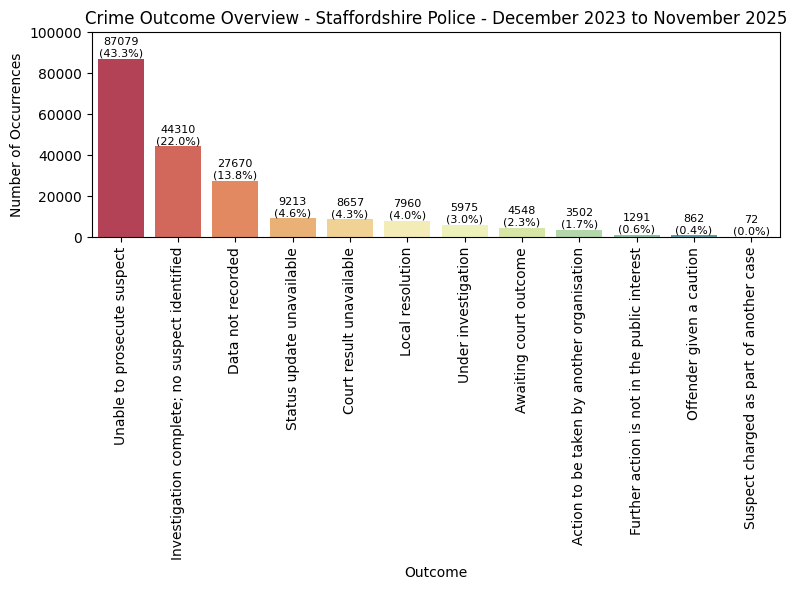

In [ ]:
#Bar Chart with percentages of total %
#Police=['West Midlands Police']
chart2=CleanData[CleanData['Reported by'].isin(Police1)]
outcome_counts = chart2['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - Staffordshire Police - December 2023 to November 2025')
plt.ylim(0, 100000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#Correlation between LSOA metrics and Crime Rate Per 12 Month/Year, not 24 Months

In [ ]:
crime_counts_lsoa = DataMerge.groupby(['LSOA name','Reported by','Population LSOA','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']).size().reset_index(name='CrimeCount')
crime_counts_lsoa['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000/2 # 12 months not total 24 months
crime_counts_lsoa['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
#crime_counts_lsoa.sort_values(by=["Weighted Crime/1000 population"],ascending=False)
crime_counts_lsoa

,LSOA name,Reported by,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),CrimeCount,Weighted Crime/1000 population
0,Ashfield 001C,Staffordshire Police,1739.0,6.0,1,0.29
1,Ashfield 012B,Staffordshire Police,1390.0,5.0,1,0.36
2,Barking and Dagenham 007D,Staffordshire Police,1981.0,4.0,1,0.25
3,Barnsley 005E,Staffordshire Police,1844.0,8.0,1,0.27
4,Barnsley 007C,Staffordshire Police,1651.0,1.0,1,0.30
...,...,...,...,...,...,...
2941,Wyre Forest 001E,Staffordshire Police,1341.0,2.0,12,4.47
2942,Wyre Forest 001F,Staffordshire Police,2493.0,5.0,1,0.20
2943,Wyre Forest 005C,Staffordshire Police,1837.0,2.0,1,0.27
2944,Wyre Forest 011E,Staffordshire Police,1393.0,3.0,1,0.36


#Creat NEW Column 'Weighted Crime/1000 WTF police' Per Year
#Creat NEW Column 'Weighted Crime/1000 population' Per Year


In [ ]:
b=crime_counts_lsoa.pivot_table(index='Reported by',values="Population LSOA",aggfunc='sum')
c=crime_counts_lsoa.pivot_table(index='Reported by',values="CrimeCount",aggfunc='sum')
e=DataMerge.pivot_table(index='Reported by',values="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",aggfunc='mean')

WorkForceFTE,b,c,e
#merge and calculate weighted data by police
d=pd.merge(c,b,on='Reported by',how='left')
f=pd.merge(d,e,on='Reported by',how='left')
weighted_data=pd.merge(f,WorkForceFTE,on='Reported by',how='left')
weighted_data.rename(columns={'Population LSOA':'Service Population'}, inplace=True)

#Decide to use official population instead than LSOA aggregates from the merged report
weighted_data.replace({2013866.0:1130000,3022894.0:2900000}, inplace=True)
#Derive normalised crime data
weighted_data['Crime/1000 population/Year']=(weighted_data['CrimeCount']/weighted_data['Service Population'].astype(float))*1000/2
weighted_data['Crime/Police FTE/Year']=(weighted_data['CrimeCount']/weighted_data['Police FTE'].astype(float))/2
weighted_data['Population/FTE']=(weighted_data['Service Population']/weighted_data['Police FTE'].astype(float))

weighted_data.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)':'IMD Decile'}, inplace=True)
weighted_data.round(1)


,Reported by,CrimeCount,Service Population,IMD Decile,Police FTE,Crime/1000 population/Year,Crime/Police FTE/Year,Population/FTE
0,Staffordshire Police,200191,1130000.0,4.2,1998,88.6,50.1,565.6
1,West Midlands Police,668108,2900000.0,3.0,8027,115.2,41.6,361.3


#Correlations
##Test of Staffordshire police indeed perform better or West Midlands Deprivation drove it more
#limitation
the LOSA data missing in the dataset, in this project we only assume the outcome based on data available
check if there is a positive correlation bettween deprevation and Crime Rate

In [ ]:
#Calculate R = -0.75, indicate a correlation coefficient of 0.75 suggested negative strong correlation
correlation_deprivation = crime_counts_lsoa.groupby(['Reported by', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
correlation_deprivation.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)':'IMD Decile'}, inplace=True)
#numerical_columns=['Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)','Weighted Crime/1000 population']
numerical_columns=['IMD Decile','Weighted Crime/1000 population']
print(correlation_deprivation[numerical_columns].corr().round(2))

                                IMD Decile  Weighted Crime/1000 population
IMD Decile                            1.00                           -0.75
Weighted Crime/1000 population       -0.75                            1.00


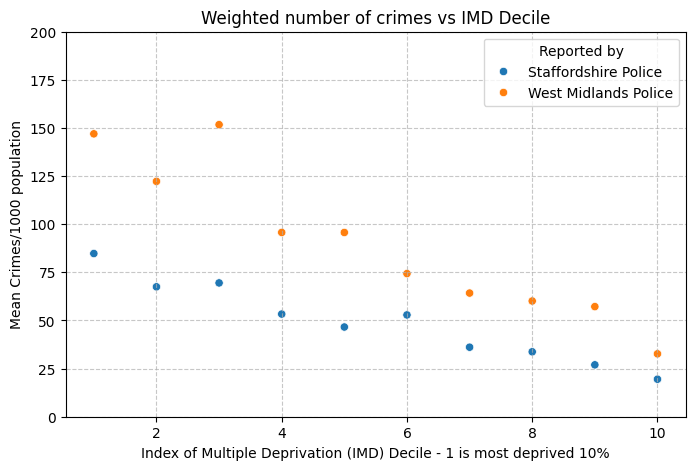

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=correlation_deprivation, x="IMD Decile", y="Weighted Crime/1000 population", hue="Reported by")
plt.title('Weighted number of crimes vs IMD Decile')
plt.xlabel('Index of Multiple Deprivation (IMD) Decile - 1 is most deprived 10%')
plt.ylabel('Mean Crimes/1000 population')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 200)
plt.show()

In [ ]:
educatiom_imd_correlation=LSOAdata.loc[:, ['Index of Multiple Deprivation (IMD) Score','Education, Skills and Training Score']]
print(educatiom_imd_correlation.corr().round(2))

                                           Index of Multiple Deprivation (IMD) Score  \
Index of Multiple Deprivation (IMD) Score                                       1.00   
Education, Skills and Training Score                                            0.89   

                                           Education, Skills and Training Score  
Index of Multiple Deprivation (IMD) Score                                  0.89  
Education, Skills and Training Score                                       1.00  


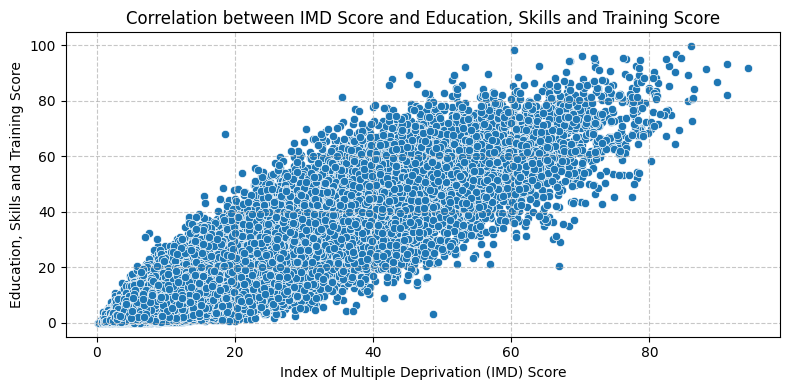

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=educatiom_imd_correlation, x='Index of Multiple Deprivation (IMD) Score', y='Education, Skills and Training Score')
plt.title('Correlation between IMD Score and Education, Skills and Training Score')
plt.xlabel('Index of Multiple Deprivation (IMD) Score')
plt.ylabel('Education, Skills and Training Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#how much each metric contribute to IMD
#Start Early
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025/english-indices-of-deprivation-2025-frequently-asked-questions#:~:text=There%20is%20not%20a%20definitive,described%20as%20'deprived').&text=Because%20there%20are%2033%2C755%20LSOAs,100/5=20).

#How likely to get away with punishment/Cost of Crime
##AntiSocial does not have outcome recorded

In [ ]:
# First, filter DataMerge by the specified Outcome
Outcome=['Unable to prosecute suspect']
Police=['West Midlands Police']
filtered_data1 = DataMerge[DataMerge['Reported by'].isin(Police)]
filtered_data2 = DataMerge[DataMerge['Last outcome category'].isin(Outcome) & DataMerge['Reported by'].isin(Police)]
# Then, group the filtered data by 'Crime type' to get the counts
crime_counts_type1 = filtered_data1.groupby(['Crime type']).size().reset_index(name='CrimeCount')
crime_counts_type2 = filtered_data2.groupby(['Crime type']).size().reset_index(name='CrimeCount-Unproscuted')
unproscuted_rate=pd.merge(crime_counts_type1,crime_counts_type2,on='Crime type',how='left')
unproscuted_rate['unproscuted_rate%']=(unproscuted_rate['CrimeCount-Unproscuted']/unproscuted_rate['CrimeCount'].astype(float))*100
unproscuted_rate['unproscuted_rate%']=unproscuted_rate['unproscuted_rate%'].round(1)
unproscuted_rate.sort_values(by=["unproscuted_rate%"],ascending=False)

,Crime type,CrimeCount,CrimeCount-Unproscuted,unproscuted_rate%
13,Violence and sexual offences,266582,190512.0,71.5
8,Public order,37459,21911.0,58.5
5,Other crime,13209,7613.0,57.6
7,Possession of weapons,12946,5442.0,42.0
3,Criminal damage and arson,50311,20694.0,41.1
6,Other theft,41491,15802.0,38.1
10,Shoplifting,62492,21738.0,34.8
11,Theft from the person,5613,1772.0,31.6
9,Robbery,14162,4372.0,30.9
1,Bicycle theft,3822,938.0,24.5


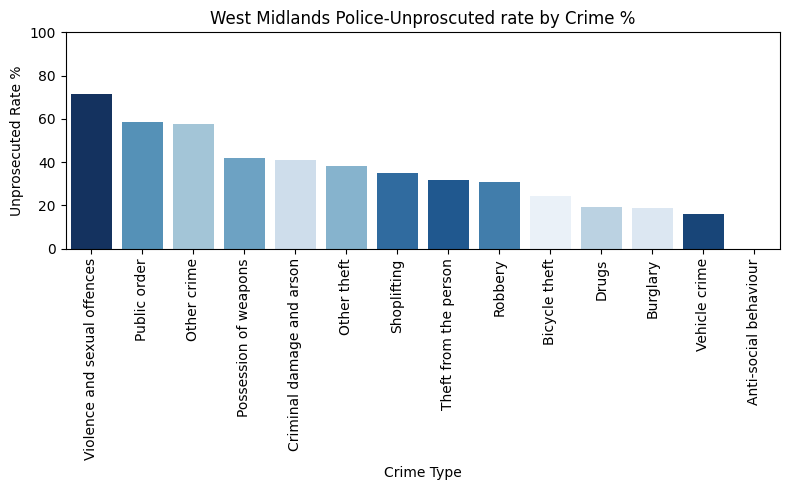

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=unproscuted_rate, x='Crime type', y='unproscuted_rate%', order=unproscuted_rate.sort_values(by='unproscuted_rate%', ascending=False)['Crime type'], hue=unproscuted_rate.index, palette='Blues', legend=False)
#hue=unproscuted_rate.index, palette='Blues', legend=False)
plt.title('West Midlands Police-Unproscuted rate by Crime %')
plt.ylim(0, 100)
plt.xlabel('Crime Type')
plt.ylabel('Unprosecuted Rate %')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()